# Week 3 Group 4: Concept Network Analysis with AI Component

This notebook analyzes concept networks with a focus on angular relationships relative to AI components.

## Table of Contents
1. [Data Loading & Preprocessing](#section1)
2. [Network Analysis](#section2)
3. [Angle Calculation (Circular Statistics)](#section3)
4. [AI-Relative Angle Analysis](#section4)
5. [Data Integration & Normalization](#section5)
6. [Visualization](#section6)
7. [Individual Analyses](#section7)

---

<a id='section1'></a>
## 1. Data Loading & Preprocessing

Loading ego network data and filtering to sessions containing 'AI' as a concept.

In [1]:
# import statements
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import networkx as nx  
from pathlib import Path
import math
from scipy.spatial.distance import euclidean
from collections import defaultdict
import seaborn as sns

In [2]:
# Part 1. Merging Ego and Alter Networks

# Set the path to our files. For me it is under this folder in 
# "Network Canvas Export Tables"
file_path = Path.cwd() / "./data/network_canvas"
file_list = file_path.glob(file_path / "*attributeList_concept.csv")

# linking keys from the file name
concept_files = [] 
for i in file_path.glob("*attributeList_concept.csv"):
    df_temp = pd.read_csv(i)
    session_id = i.name.split("_")[1]
    df_temp["session_id"] = session_id
    concept_files.append(df_temp)

# Concatenate all the alter files, then reset the index
df_alters = pd.concat(concept_files)
df_alters.reset_index()

# merge where df_alter["session_id"] == ["networkCanvasSessionID"]
ego_files = []
for i in file_path.glob("*_ego.csv"):
    ego_files.append( pd.read_csv(i))

df_ego = pd.concat(ego_files)

df_alters = df_alters.merge(df_ego, left_on="session_id", right_on="networkCanvasSessionID")

# Filter: Keep only sessions that contain 'AI' as a concept
sessions_with_ai = df_alters[df_alters['name'] == 'AI']['session_id'].unique()
df_alters = df_alters[df_alters['session_id'].isin(sessions_with_ai)]
print(f"Filtered to {len(sessions_with_ai)} sessions with 'AI' component")

# check the value_counts of the name variable
df_alters["name"].value_counts()

Filtered to 15 sessions with 'AI' component


name
AI                 15
ethics             10
technology         10
analysis            9
knowledge           9
empirical data      9
theory              7
context             7
community           6
perspective         6
truth               6
optimisation        5
social networks     5
change              5
culture             5
structure           4
progress            4
identity            4
development         4
policy              4
inequality          4
social norms        3
power               3
macro-micro         3
design              2
justice             2
user experience     2
privacy             2
art                 1
personal            1
gender              1
music               1
freedom             1
history             1
collective          1
individual          1
race-ethnicity      1
Name: count, dtype: int64

In [3]:
# Part 2. Merging in Giant Component data

# build a dictionary {"sessionID":file_path}
# Only process sessions that contain AI
edge_list = []
for i in file_path.glob("*ego.csv"):
    x = i.name.split("_")[:-1]
    x.append("edgeList_relate.csv")
    edge_path = Path(file_path / "_".join(x))
    key = i.name.split("_")[1]
    
    # Skip sessions without AI component
    if key not in sessions_with_ai:
        continue
    
    if edge_path.exists():
        edge_list.append(
            {"key":key,
             "path":edge_path
             })
    else:
        raise Exception("Warning: The edge path file does not exist.") 


# For each path we create a network. 
# reading the CSV to a DataFrame
# taking the source and target columns as lists
# zipping the list: this way instead of [1,2,3,4], [a,b,c,d] we have [(1,a), (2,b), (3,c), (4,d)]

edgelist_dfs = []
for edge_file in edge_list:
    edge_df = pd.read_csv(edge_file["path"])
    edges = zip(edge_df["networkCanvasSourceUUID"].to_list(),edge_df["networkCanvasTargetUUID"].to_list())
    edges = list(edges)
    G = nx.Graph(edges)
        
    # Once we have the zipped list, these are the edges. We can then check the giant component.
    ccs = sorted(list(nx.connected_components(G)), key=len, reverse=True)

    # Sort components to check if same length
    giant_component = ccs[0]
    if len(ccs) > 1:
        for i in ccs[1:]:
            if len(i) == len(ccs[0]):
                giant_component.extend(i)

    # Now we create a temporary dataframe with two columns: 
    # networkCanvasUUID (which is the ID of the concept)
    # networkCanvasSessionID (which is the joining key)
    df_temp = pd.DataFrame(giant_component, columns=["networkCanvasUUID"])
    df_temp["networkCanvasSessionID"] = edge_file["key"]
    # And we add "in_gcc" = 1, later we populate all the rest as 0
    df_temp["in_gcc"] = 1
    edgelist_dfs.append(df_temp)

# We concatenate all the components into a single DataFrame
df_edgelist_gcc = pd.concat(edgelist_dfs) 
df_alters = df_alters.merge(df_edgelist_gcc, on=["networkCanvasSessionID","networkCanvasUUID"], how="left")

# Where we didn't get a value from the merge, that node was not in the giant component for that ego
df_alters.fillna({"in_gcc":0}, inplace = True)

df_alters["in_gcc"].value_counts()

in_gcc
1.0    125
0.0     39
Name: count, dtype: int64

---

<a id='section2'></a>
## 2. Network Analysis

Aggregating concept data and analyzing network properties.

# Q2. Aggregating networks

Now with your `df_alter` DataFrame table, aggregate over the concepts to produce `df_concepts`, counting:
  - the number of times they appear 
  - the number of times they appear in the giant component

Q2.1: Descriptive questions: 
- How many concepts appear in total? 
- Which concept appears the most? Please produce a table ranking the concepts from most to least common. 

# Q2 Answer below here 

Please use markdown or python cells as necessary. 

In [4]:
# We filter first to the columns of interest: name and 'in_gcc'
# Then we groupby and get a count of these as well as a sum.
# Count will get us how many times the concept appeared; 
# Sum will get us how many times it appeared in the giant component.
df_concepts = df_alters[["name","in_gcc"]].groupby("name").agg(["count","sum"])
df_concepts.columns = ["concept_count", "concept_sum"]
df_concepts.sort_values("concept_count",ascending=False,inplace=True)
df_concepts

,concept_count,concept_sum
name,,
AI,15,12.0
technology,10,9.0
ethics,10,8.0
knowledge,9,7.0
analysis,9,8.0
empirical data,9,8.0
theory,7,6.0
context,7,6.0
perspective,6,5.0


Calculated distance for 37 concepts

Top 10 concepts closest to center:
                mentions  distance
name                              
design                 2  0.081255
collective             1  0.083550
freedom                1  0.085239
history                1  0.103096
individual             1  0.107629
personal               1  0.109637
community              6  0.116061
empirical data         9  0.119160
truth                  6  0.129760
analysis               9  0.131422


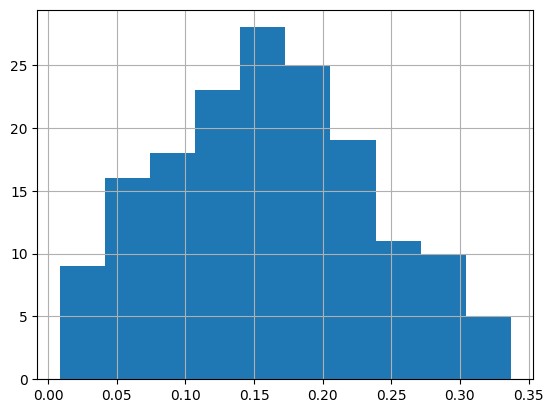

In [5]:
# EUCLIDEAN DISTANCE FROM CENTER
# Calculate distance from center (0.5, 0.5) for each concept
# distance = np.linalg.norm([x - 0.5, y - 0.5])
df_alters['distance'] = df_alters.apply(
    lambda row: np.linalg.norm([row['user_layout_x'] - 0.5, row['user_layout_y'] - 0.5]), 
    axis=1
)

# Visualize distance distribution
df_alters["distance"].hist()

# Aggregate by concept: count mentions and mean distance
df_concepts_2 = df_alters[["name","distance"]].groupby("name").agg(["count","mean"])
df_concepts_2.columns = ["mentions","distance"]

# Sort by distance
df_concepts_2.sort_values("distance", inplace=True)

print(f"Calculated distance for {len(df_concepts_2)} concepts")
print(f"\nTop 10 concepts closest to center:")
print(df_concepts_2.head(10))


In [6]:
# NEAREST ANGLE NODE

# Function to calculate smallest angular distance
def angular_distance(angle1, angle2):
    """Calculate smallest angular distance between two angles (in radians)"""
    diff = np.abs(angle1 - angle2)
    return np.minimum(diff, 2*np.pi - diff)

# Find nearest node by angle within each ego network
def find_nearest_node_in_egonet(group):
    """Helper function to find nearest angle within a group"""
    angles = group['angle_rad'].values
    indices = group.index.values
    n = len(angles)
    
    # Edge case: single node
    if n <= 1:
        return pd.Series([None] * n, index=indices)
    
    # Create angular distance matrix
    angle_diff = np.abs(angles[:, None] - angles[None, :])
    angular_dist = np.minimum(angle_diff, 2*np.pi - angle_diff)
    
    # Set diagonal to infinity (avoid self-matching)
    np.fill_diagonal(angular_dist, np.inf)
    
    # Get nearest index for each row
    nearest_positions = np.argmin(angular_dist, axis=1)
    nearest_indices = indices[nearest_positions]
    
    return pd.Series(nearest_indices, index=indices)

def find_nearest_node(df, category):
    """Vectorized version using groupby"""
    nearest_node = (df
                    .groupby(category, group_keys=False)
                    .apply(find_nearest_node_in_egonet, include_groups=False))
    return nearest_node.map(df_alters['name'])

# Calculate angle in radians if not already present
if 'angle_rad' not in df_alters.columns:
    df_alters['angle_rad'] = np.arctan2(
        df_alters['user_layout_x'] - 0.5, 
        df_alters['user_layout_y'] - 0.5
    )

# Find nearest angle node for each concept
df_alters['nearest_angle_node'] = find_nearest_node(df_alters, "session_id")

# Aggregate by concept: most common nearest neighbor
df_concepts_3 = df_alters[["name","nearest_angle_node"]].groupby("name").agg(
    lambda x: x.mode()[0] if not x.mode().empty else None
)

print(f"Calculated nearest angle node for {len(df_concepts_3)} concepts")
print(f"\nSample of nearest angle nodes:")
print(df_concepts_3.head(10))


Calculated nearest angle node for 37 concepts

Sample of nearest angle nodes:
            nearest_angle_node
name                          
AI                      ethics
analysis          optimisation
art                         AI
change                  ethics
collective             justice
community             identity
context                     AI
culture                context
design                   music
development         technology


From the above analysis we can see that a few terms that were not mentioned often tended to be at the same time, the concepts most close to a given person. Thus when we look at the most common concepts, such as AI and ethics, these might not be the most important concepts for someone but a sort of key common concept. 

By visualising the distance as a histogram we can see that most of the nodes were around ring 2 or 3 (assuming that sqrt(2), being right in the corner, is the max distance, but rarely used).

---

<a id='section3'></a>
## 3. Circular Statistics: Concept Angle Calculation

Calculating the mean angular position of each concept using circular statistics. This helps us understand the spatial distribution of concepts in the network visualization.

**Key Metrics:**
- **Mean angle**: Average angular position (using circular mean for angles)
- **Resultant length (R)**: Concentration measure (0=scattered, 1=tightly clustered)
- **Minimum appearances**: Filter concepts that appear at least 2 times

**Note:** Circular statistics are necessary because angles wrap around (0° = 360°).

In [7]:

# Calculate basic angle for each concept (used in circular statistics)
import numpy as np
df_alters['angle_rad'] = np.arctan2(
    df_alters['user_layout_x'] - 0.5, 
    df_alters['user_layout_y'] - 0.5
)
print("✓ Calculated angle_rad for alters")


✓ Calculated angle_rad for alters


In [8]:

#column names used 
CONCEPT = 'name'
ANGLE_COL = 'angle_rad'  
MIN_APPEAR = 1    

# Make sure angle_rad exists. if not, compute it
if ANGLE_COL not in df_alters.columns:
    df_alters[ANGLE_COL] = np.arctan2(df_alters['user_layout_x'] - 0.5,
                                      df_alters['user_layout_y'] - 0.5)

# Drop rows with missing angle values
df_angles_work = df_alters[[CONCEPT, ANGLE_COL]].dropna(subset=[ANGLE_COL]).copy()
df_angles_work[ANGLE_COL] = df_angles_work[ANGLE_COL].astype(float)

# Function to compute circular mean & resultant length for an array of angles
def circular_stats(angles):
    """Return (n, mean_angle_rad, mean_angle_deg, resultant_length R in [0,1])."""
    angles = np.asarray(angles, dtype=float)
    n = angles.size
    if n == 0:
        return 0, np.nan, np.nan, np.nan
    mean_sin = np.mean(np.sin(angles))
    mean_cos = np.mean(np.cos(angles))
    mean_angle = np.arctan2(mean_sin, mean_cos)           # circular mean in radians
    mean_angle_deg = np.degrees(mean_angle)              
    R = np.sqrt(mean_sin**2 + mean_cos**2)               # resultant length (concentration)
    return n, mean_angle, mean_angle_deg, R

# Group by concept and compute circular stats
rows = []
for concept, g in df_angles_work.groupby(CONCEPT, sort=True):
    n, mean_angle_rad, mean_angle_deg, R = circular_stats(g[ANGLE_COL].values)
    if n < MIN_APPEAR:
        continue
    rows.append({
        CONCEPT: concept,
        'n_appearances': int(n),
        'mean_angle_rad': float(mean_angle_rad),
        'mean_angle_deg': float(mean_angle_deg),
        'resultant_length': float(R)   # R near 1 -> tight clustering in angle; near 0 -> scattered
    })

df_concept_angles = pd.DataFrame(rows).sort_values('n_appearances', ascending=False).reset_index(drop=True)

try:
    df_c3 = df_concepts_3.reset_index().rename(columns={'index':'name'})
except Exception:
    df_c3 = df_concepts_3.copy()
if 'name' not in df_c3.columns:
    df_c3 = df_c3.reset_index().rename(columns={'index':'name'})

df_concepts_3_with_angle = df_c3.merge(df_concept_angles, how='left', left_on='name', right_on=CONCEPT)

# show results
print("Top concept angles (sample):")
print(df_concept_angles.head(20))

Top concept angles (sample):
               name  n_appearances  mean_angle_rad  mean_angle_deg  \
0                AI             15       -0.800271      -45.852166   
1        technology             10        0.092245        5.285275   
2            ethics             10       -2.118975     -121.408337   
3         knowledge              9        3.134290      179.581568   
4          analysis              9        0.911683       52.235568   
5    empirical data              9        0.024277        1.390972   
6            theory              7       -3.107817     -178.064794   
7           context              7       -3.098590     -177.536136   
8       perspective              6       -1.749452     -100.236221   
9         community              6        2.007824      115.039869   
10            truth              6       -2.992788     -171.474129   
11          culture              5        1.484828       85.074398   
12  social networks              5        0.066420        3.8

In [9]:
df_concept_angles.set_index('name', inplace=True)

# Check it worked
print(df_concept_angles.head())

# Concatenate concept dataframes (df_concepts_3 removed as nearest_angle_node not used)
df_concepts_all = pd.concat([df_concepts, df_concepts_2, df_concept_angles], axis=1)

# inspect and save
print(df_concepts_all.head())
df_concepts_all.to_csv("concepts_summary_all.csv")


            n_appearances  mean_angle_rad  mean_angle_deg  resultant_length
name                                                                       
AI                     15       -0.800271      -45.852166          0.343651
technology             10        0.092245        5.285275          0.095279
ethics                 10       -2.118975     -121.408337          0.348042
knowledge               9        3.134290      179.581568          0.535364
analysis                9        0.911683       52.235568          0.094295
            concept_count  concept_sum  mentions  distance  n_appearances  \
name                                                                        
AI                     15         12.0        15  0.135176             15   
technology             10          9.0        10  0.138378             10   
ethics                 10          8.0        10  0.148323             10   
knowledge               9          7.0         9  0.154507              9   
analys

---

<a id='section4'></a>
## 4. AI-Relative Angle Analysis

Calculating angular relationships between AI and other concepts. This analysis focuses on how concepts are positioned relative to AI in the conceptual space.

**Methodology:**
1. Filter to sessions containing 'AI'
2. Calculate angular difference between AI and each other concept
3. Compute mean angles and statistics per concept
4. Normalize to 0-180° range (upper semicircle)

In [10]:
# Define angle calculation functions
def angle_from_center(x, y, center_x=0.5, center_y=0.5):
    """Calculate angle from center point to (x,y) relative to positive X-axis [0,360)."""
    ang = math.degrees(math.atan2(y - center_y, x - center_x))
    if ang < 0:
        ang += 360.0
    return ang

def angular_difference(angle1, angle2):
    """Calculate minimum angular difference between two angles [0,180]."""
    diff = abs(angle1 - angle2)
    return min(diff, 360.0 - diff)

def circular_mean_deg(angles_deg):
    """Return circular mean (degrees [0,360)) or None if undefined/empty."""
    if len(angles_deg) == 0:
        return None
    a = np.deg2rad(np.array(angles_deg, dtype=float))
    s, c = np.sin(a).sum(), np.cos(a).sum()
    # if vector sum is essentially zero then undefined mean
    if np.isclose(s, 0.0) and np.isclose(c, 0.0):
        return None
    mean_ang = math.degrees(math.atan2(s, c))
    if mean_ang < 0:
        mean_ang += 360.0
    return mean_ang

# setting the directory path
data_dir = Path('./data/network_canvas') 

# Load and process the data 
def load_csv_files(pattern):
    dfs = []
    for file in data_dir.glob(pattern):
        df = pd.read_csv(file)
        df['source_file'] = file.name
        dfs.append(df)
    
    if dfs:
        return pd.concat(dfs, ignore_index=True)
    return None

# Load different types of files
attr_df = load_csv_files("*_attributeList_concept.csv")
ego_df = load_csv_files("*_ego.csv")

# Get SessionID
attr_df['SessionID'] = attr_df['source_file'].str.extract(r'Anonymous Participant_([\w]+)_attributeList_concept\.csv')
ego_df['SessionID'] = ego_df['source_file'].str.extract(r'Anonymous Participant_([\w]+)_ego\.csv')

# Merge
df_alter = pd.merge(attr_df, ego_df, on='SessionID', suffixes=('_attr', '_ego'))
print(f"Loaded {len(df_alter)} rows, {df_alter['SessionID'].nunique()} sessions, {df_alter['name'].nunique()} concepts")


Loaded 186 rows, 17 sessions, 38 concepts


In [11]:
# Filter to only ego spaces (sessions) that contain "AI"
sessions_with_ai = df_alter[df_alter['name'] == 'AI']['SessionID'].unique()
df_alter_with_ai = df_alter[df_alter['SessionID'].isin(sessions_with_ai)].copy()
print(f"Filtered to {len(sessions_with_ai)} sessions with 'AI' ({len(df_alter_with_ai)} rows)")


Filtered to 15 sessions with 'AI' (164 rows)


In [12]:
# Calculate angles between AI and every other component in each session
angle_records = []

for session_id in sessions_with_ai:
    session_data = df_alter_with_ai[df_alter_with_ai['SessionID'] == session_id]
    ai_data = session_data[session_data['name'] == 'AI']
    
    if len(ai_data) == 0:
        continue
    
    # Calculate AI's angle from center relative to X-axis
    ai_x, ai_y = ai_data['user_layout_x'].values[0], ai_data['user_layout_y'].values[0]
    ai_angle = angle_from_center(ai_x, ai_y)
    
    for idx, row in session_data.iterrows():    
        # Calculate concept's angle from center relative to X-axis
        concept_angle = angle_from_center(row['user_layout_x'], row['user_layout_y'])
        
        # Calculate angular difference (0-180)
        angle = angular_difference(ai_angle, concept_angle)
        
        angle_records.append({
            'session_id': session_id,
            'concept': row['name'],
            'angle_deg': angle
        })

df_ai_angles = pd.DataFrame(angle_records)
print(f"Calculated {len(df_ai_angles)} angle measurements")
df_ai_angles.head(10)


Calculated 164 angle measurements


,session_id,concept,angle_deg
0,cmh1ulurw000lsa2750fqbpip,AI,0.000000
1,cmh1ulurw000lsa2750fqbpip,analysis,104.510752
2,cmh1ulurw000lsa2750fqbpip,context,56.392336
3,cmh1ulurw000lsa2750fqbpip,empirical data,171.605306
4,cmh1ulurw000lsa2750fqbpip,ethics,29.398746
5,cmh1ulurw000lsa2750fqbpip,optimisation,112.796057
6,cmh1ulurw000lsa2750fqbpip,personal,107.893191
7,cmh1ulurw000lsa2750fqbpip,progress,35.855787
8,cmh1ulurw000lsa2750fqbpip,social networks,128.577096
9,cmh1ulurw000lsa2750fqbpip,change,78.987004


In [13]:
# Calculate mean angle for each concept with AI (in radians)
summary_records = []

for concept in df_ai_angles['concept'].unique():
    concept_angles = df_ai_angles[df_ai_angles['concept'] == concept]['angle_deg'].values
    
    # For angular differences (0-180), use simple mean
    mean_angle_deg = np.mean(concept_angles)
    mean_angle_rad = np.deg2rad(mean_angle_deg)
    
    summary_records.append({
        'concept': concept,
        'occurrence_count': len(concept_angles),
        'mean_angle_rad': mean_angle_rad,
        'mean_angle_deg': mean_angle_deg,
        'angle_std': np.std(concept_angles)
    })

df_ai_summary = pd.DataFrame(summary_records).sort_values('occurrence_count', ascending=False).reset_index(drop=True)

# keep 0-180° range for upper half circle visualization
df_ai_summary.to_csv('ai_component_angles_summary.csv', index=False)
max_angle = df_ai_summary['mean_angle_deg'].max()
print(f"Saved summary. Angles in 0-180° range (max: {max_angle:.2f}°) for upper half circle plot")
df_ai_summary


Saved summary. Angles in 0-180° range (max: 156.89°) for upper half circle plot


,concept,occurrence_count,mean_angle_rad,mean_angle_deg,angle_std
0,AI,15,0.000000,0.000000,0.000000
1,ethics,10,1.437191,82.344990,47.208374
2,technology,10,1.491316,85.446105,55.990473
3,analysis,9,1.619334,92.780985,48.363297
4,knowledge,9,1.646900,94.360446,59.485674
5,empirical data,9,1.875103,107.435494,56.873402
6,theory,7,1.946488,111.525533,49.319807
7,context,7,1.306939,74.882061,30.714789
8,community,6,1.942932,111.321800,48.881318
9,perspective,6,2.072390,118.739172,54.933436


---

## <a id='section5'></a> 5. Data Integration & Normalization
Merging the AI-relative angles with the main concept dataframe and normalizing for visualization.

In [14]:
# Merge with AI angle data
df_concepts_all = df_concepts_all.reset_index()
df_concepts_all = df_concepts_all.merge(
    df_ai_summary[['concept', 'mean_angle_deg', 'occurrence_count', 'angle_std']], 
    left_on='name', 
    right_on='concept', 
    how='left',
    suffixes=('_orig', '_ai')
)

# Replace angles with AI-relative angles (if available)
df_concepts_all['mean_angle_deg'] = df_concepts_all['mean_angle_deg_ai'].fillna(df_concepts_all['mean_angle_deg_orig'])

# Normalize to 0-180° (stretch max to 180°)
max_angle = df_concepts_all['mean_angle_deg'].max()
df_concepts_all['mean_angle_deg_normalized'] = (df_concepts_all['mean_angle_deg'] / max_angle) * 180
df_concepts_all['mean_angle_rad_normalized'] = np.deg2rad(df_concepts_all['mean_angle_deg_normalized'])

# Mark which have AI angles
df_concepts_all['has_ai_angle'] = df_concepts_all['mean_angle_deg_ai'].notna()

# Clean up
df_concepts_all = df_concepts_all.drop(columns=['concept', 'mean_angle_deg_orig', 'mean_angle_deg_ai'], errors='ignore')

print(f"Loaded {len(df_concepts_all)} concepts")
print(f"Max angle: {max_angle:.2f}° → normalized to 180°")
print(f"With AI angles: {df_concepts_all['has_ai_angle'].sum()}")

Loaded 37 concepts
Max angle: 156.89° → normalized to 180°
With AI angles: 37


---

<a id='section6'></a>
## 6. Circular Map Visualization

Creating a polar coordinate visualization where:
- **Angle**: Normalized AI-relative angle (0-180°, upper semicircle)
- **Distance**: Distance from center in the original network layout
- **Size**: Logarithmic scale of concept frequency
- **Color**: Salmon (uniform for all concepts)

This visualization maps concepts in a circular layout showing their angular relationship to AI.

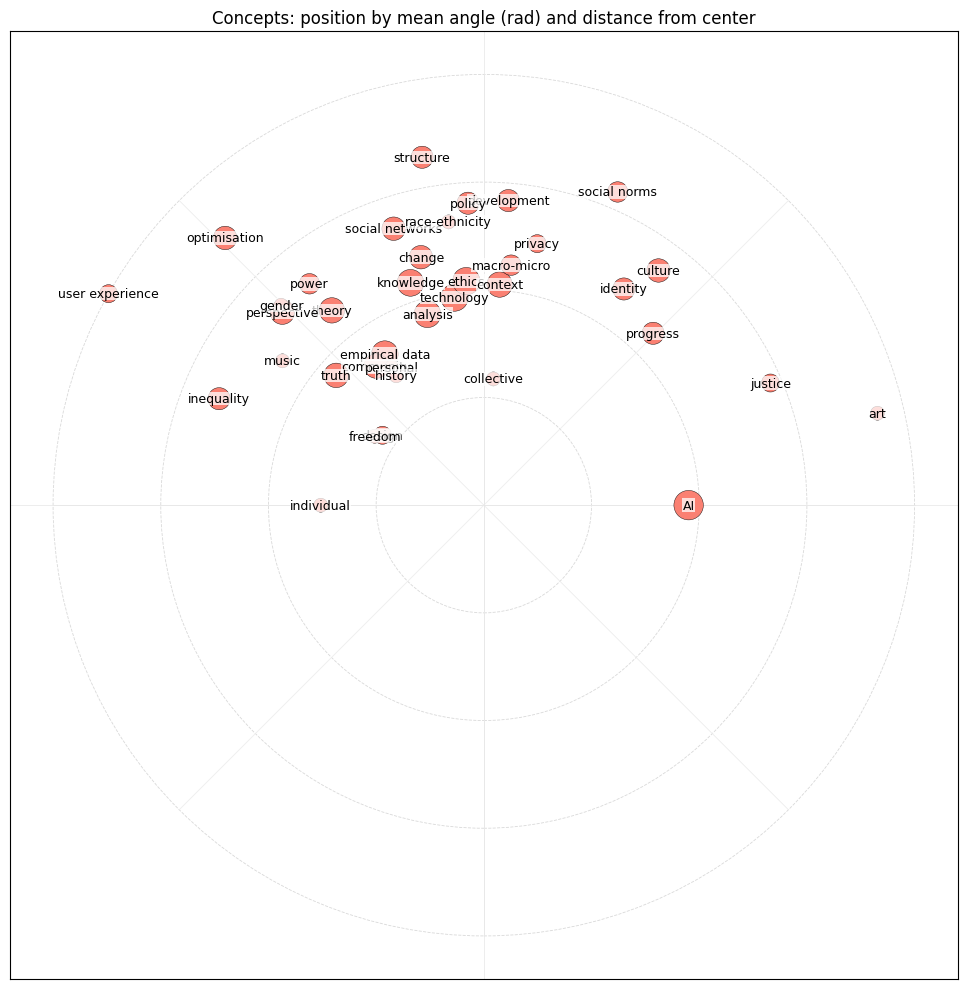

Plotted 37 concepts. Saved to concepts_circular_map.png


In [15]:

DF = df_concepts_all            # final dataframe
ANGLE_COL = 'mean_angle_rad_normalized'    # radians
DIST_COL = 'distance'           # euclidean distance from center
FREQ_COL = 'concept_count'
FIGSIZE = (10,10)
SAVE_PATH = 'concepts_circular_map.png'
GUIDE_CIRCLES = True
MAX_LABELS = None   # None = label all; or set int to label top-N by frequency

# Basic checks
if ANGLE_COL not in DF.columns and ANGLE_COL not in DF.index:
    raise KeyError(f"Angle column '{ANGLE_COL}' not found in df_concepts_all. Columns: {list(DF.columns)}")
if DIST_COL not in DF.columns:
    raise KeyError(f"Distance column '{DIST_COL}' not found in df_concepts_all. Columns: {list(DF.columns)}")

# ensure index is name
df = DF.copy()
if 'name' in df.columns:
    df = df.set_index('name')

# select and drop missing rows
cols_needed = [ANGLE_COL, DIST_COL]
df_plot = df[cols_needed + [c for c in ([FREQ_COL]) if c in df.columns]].copy()
df_plot = df_plot.dropna(subset=[ANGLE_COL, DIST_COL])

# extract plotting arrays
thetas = df_plot[ANGLE_COL].astype(float).values   # radians
rs     = df_plot[DIST_COL].astype(float).values

# polar -> cartesian (center at 0,0)
xs = rs * np.cos(thetas)
ys = rs * np.sin(thetas)
df_plot['_x'] = xs
df_plot['_y'] = ys


# marker sizes based on log(concept_count)
if 'concept_count' not in df_plot.columns:
    raise KeyError("'concept_count' column not found in df_concepts_all.")

# compute log-scaled sizes (add 1 to avoid log(0))
freq = np.log1p(df_plot['concept_count'].astype(float))

# normalize to a visual range 
s_min, s_max = 100, 450
if freq.max() == freq.min():
    sizes = np.full_like(freq, (s_min + s_max) / 2)
else:
    sizes = s_min + (freq - freq.min()) / (freq.max() - freq.min()) * (s_max - s_min)


# Use one color for all nodes
colors = 'salmon'      # or any Matplotlib color name, e.g. 'gray', 'crimson', '#1f77b4'
colorbar_label = None     # no colorbar needed


# choose labels (optionally top-N by freq)
if MAX_LABELS and FREQ_COL in df_plot.columns:
    label_idx = df_plot.sort_values(FREQ_COL, ascending=False).head(MAX_LABELS).index
elif MAX_LABELS:
    label_idx = df_plot.index[:MAX_LABELS]
else:
    label_idx = df_plot.index

# --- Plot ---
fig, ax = plt.subplots(figsize=FIGSIZE)
ax.set_aspect('equal')

# scatter nodes
scatter = ax.scatter(df_plot['_x'], df_plot['_y'], s=sizes, c=colors, edgecolor='k', linewidth=0.3, zorder=3)

# guide circles and radial lines
if GUIDE_CIRCLES:
    max_r = np.nanmax(rs) if len(rs)>0 else 1.0
    circles = np.linspace(0, max_r, 5)[1:]
    for r in circles:
        ax.add_artist(plt.Circle((0,0), r, color='0.85', fill=False, linestyle='--', linewidth=0.6, zorder=0))
    for deg in range(0, 360, 45):
        theta = np.deg2rad(deg)
        ax.plot([0, max_r*np.cos(theta)], [0, max_r*np.sin(theta)], color='0.93', linewidth=0.6, zorder=0)

# labels
for name in label_idx:
    row = df_plot.loc[name]
    ax.text(row['_x'], row['_y'], str(name), fontsize=9, ha='center', va='center',
            bbox=dict(facecolor='white', alpha=0.75, edgecolor='none', pad=0.2), zorder=4)

# optional colorbar
if colorbar_label:
    import matplotlib as mpl
    norm = mpl.colors.Normalize(vmin=vals.min(), vmax=vals.max())
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label(colorbar_label)

# cosmetics (center intentionally left empty)
ax.axhline(0, color='0.9', linewidth=0.5)
ax.axvline(0, color='0.9', linewidth=0.5)
ax.set_title('Concepts: position by mean angle (rad) and distance from center')
ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.savefig(SAVE_PATH, dpi=300)
plt.show()

print(f"Plotted {len(df_plot)} concepts. Saved to {SAVE_PATH}")


<a id='section7'></a>
## 6. Individual Analyses

### Fuzzy Concepts

,AI,analysis,context,empirical data,ethics,optimisation,personal,progress,social networks,change,...,structure,development,art,design,justice,music,collective,history,individual,user experience
AI,0,0.195728,0.244217,0.213134,0.169079,0.296722,0.279658,0.169614,0.279036,0.185773,...,0.315211,0.171462,0.22856,0.182579,0.153865,0.189111,0.097076,0.181882,0.310273,0.445278
analysis,0.195728,0,0.257675,0.16335,0.207046,0.231789,0.229443,0.204101,0.44796,0.255441,...,0.336052,0.253041,NaN,NaN,0.14683,NaN,0.172987,NaN,0.103967,0.281567
context,0.244217,0.257675,0,0.173951,0.238654,0.278605,0.184965,0.290917,0.238062,0.276951,...,0.276796,0.261258,NaN,0.094067,NaN,NaN,0.245827,0.083406,0.140799,0.230794
empirical data,0.213134,0.16335,0.173951,0,0.204641,0.279805,0.10198,0.185259,0.265687,0.235694,...,0.278027,0.172479,NaN,NaN,0.07952,NaN,0.164283,0.188604,NaN,NaN
ethics,0.169079,0.207046,0.238654,0.204641,0,0.302118,0.199276,0.215418,0.34083,0.112162,...,0.180557,0.333262,NaN,NaN,0.207121,NaN,0.080635,0.232886,0.243435,0.386417
optimisation,0.296722,0.231789,0.278605,0.279805,0.302118,0,0.412113,0.381693,0.292282,0.219374,...,0.238139,0.456117,NaN,0.222149,NaN,NaN,0.326843,NaN,NaN,0.091122
personal,0.279658,0.229443,0.184965,0.10198,0.199276,0.412113,0,0.322831,0.14113,0.326896,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
progress,0.169614,0.204101,0.290917,0.185259,0.215418,0.381693,0.322831,0,0.31944,0.164063,...,NaN,0.086198,NaN,0.177516,NaN,NaN,NaN,NaN,NaN,0.337775
social networks,0.279036,0.44796,0.238062,0.265687,0.34083,0.292282,0.14113,0.31944,0,0.391351,...,0.147534,0.270323,NaN,0.191592,NaN,NaN,0.53027,NaN,NaN,0.272691
change,0.185773,0.255441,0.276951,0.235694,0.112162,0.219374,0.326896,0.164063,0.391351,0,...,0.394072,0.334788,NaN,NaN,0.222783,NaN,0.229925,NaN,NaN,NaN


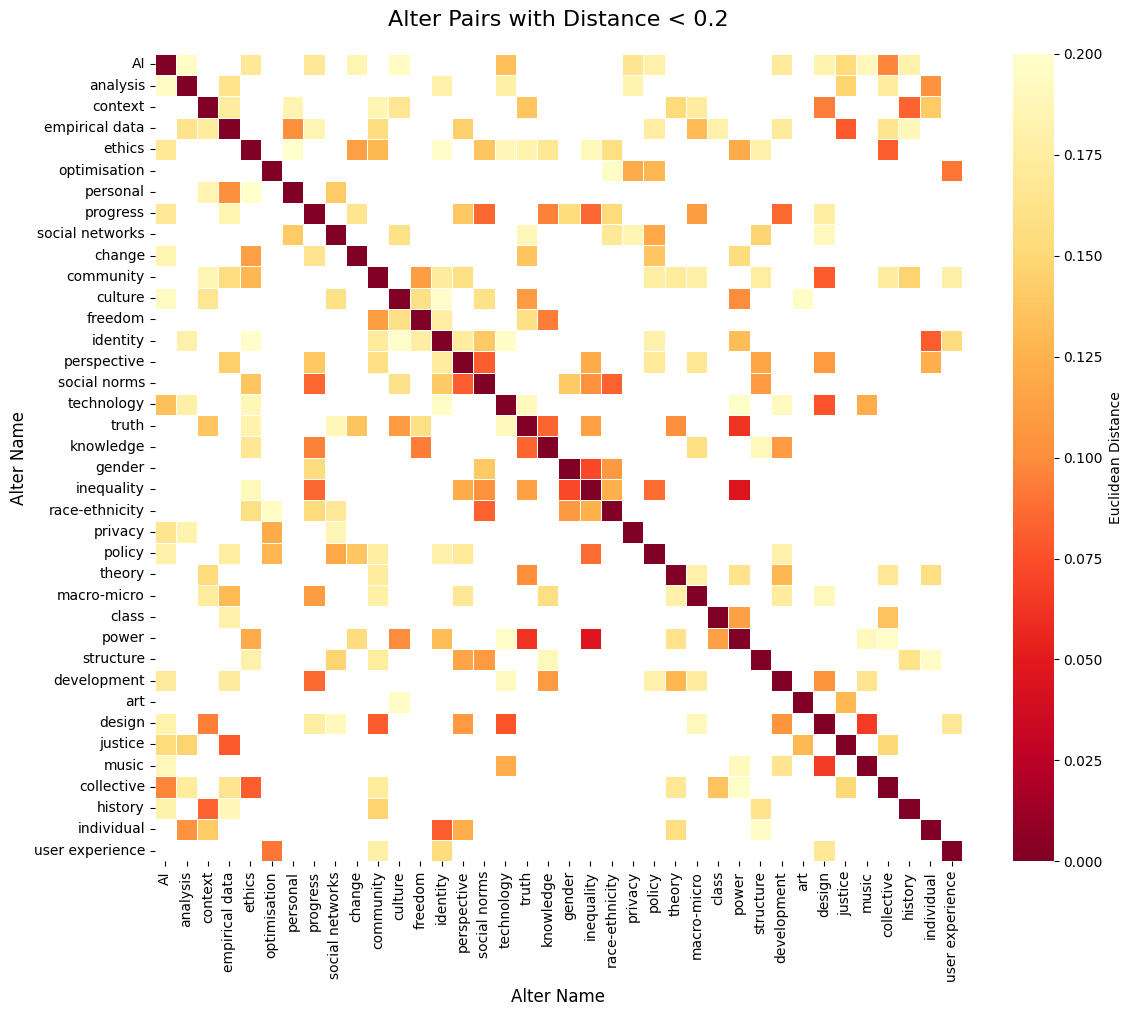

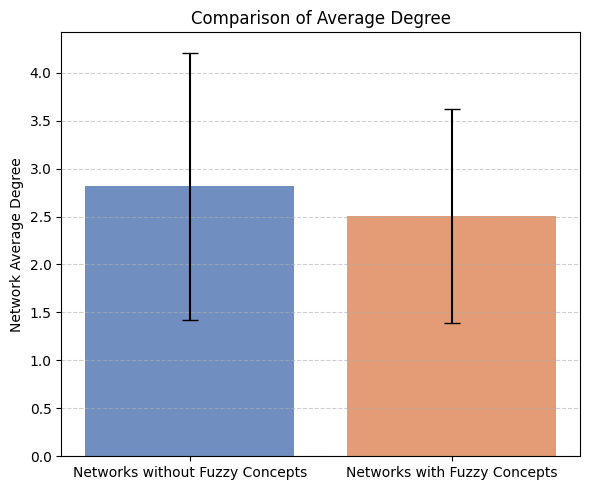

In [16]:
def relative_distance(df_alter):
    
    # Get unique alter names
    unique_alters = df_alter['name'].unique()

    # Dictionary to store distances for each pair across sessions
    pair_distances = defaultdict(list)

    # Calculate distances for each session
    for session_id in df_alter['SessionID'].unique():
        df_temp = df_alter[df_alter['SessionID'] == session_id]
        
        for i in df_temp['name'].unique():
            for j in df_temp['name'].unique():
                if i != j:
                    vec_i = df_temp[df_temp['name'] == i][['user_layout_x', 'user_layout_y']].values.flatten()
                    vec_j = df_temp[df_temp['name'] == j][['user_layout_x', 'user_layout_y']].values.flatten()
                    
                    # Only calculate if both vectors exist and are not empty
                    if len(vec_i) > 0 and len(vec_j) > 0:
                        dist = euclidean(vec_i, vec_j)
                        pair_distances[(i, j)].append(dist)

    # Create dataframe and populate with averaged distances
    df_relative = pd.DataFrame(index=unique_alters, columns=unique_alters)

    for (i, j), distances in pair_distances.items():
        df_relative.loc[i, j] = np.mean(distances)

    # Optional: fill diagonal with 0 (distance from alter to itself)
    np.fill_diagonal(df_relative.values, 0)

    display(df_relative)

    return df_relative

def plot_relative_distance_heatmap(df_relative):
    # Create a mask for values >= 0.2
    mask = df_relative.astype(float) >= 0.2

    # Create heatmap
    plt.figure(figsize=(12, 10))
    sns.heatmap(df_relative.astype(float), 
                annot=False,  # Don't show values
                cmap='YlOrRd_r',
                mask=mask,  # Hide values >= 0.2
                cbar_kws={'label': 'Euclidean Distance'},
                linewidths=0.5,
                square=True,
                vmin=0,
                vmax=0.2)  # Set color scale to 0-0.2 range

    plt.title('Alter Pairs with Distance < 0.2', fontsize=16, pad=20)
    plt.xlabel('Alter Name', fontsize=12)
    plt.ylabel('Alter Name', fontsize=12)
    plt.tight_layout()
    plt.show()

df_relative = relative_distance(df_alter)
plot_relative_distance_heatmap(df_relative)

# filter out the index where the relative distance is less that 0.05
for_ai = df_relative.index[df_relative["AI"] > 0.3].tolist()
for_ai

# filter for SessionID where for_ai nodes are present
sessions_far_ai = (
    df_alter.loc[df_alter['name'].isin(for_ai), 'SessionID']
    .dropna()
    .unique()
    .tolist()
)
all_sessions = df_alter['SessionID'].dropna().unique().tolist()
sessions_close_ai = [s for s in all_sessions if s not in sessions_far_ai]

degree_close_ai = [] 
degree_far_ai = [] 

for session in all_sessions: 

    df_temp = df_alter[df_alter['SessionID'] == session]
    edge_file_path = data_dir / f'Anonymous Participant_{session}_edgeList_relate.csv'
    edge_df = pd.read_csv(edge_file_path)
    edges_named = (
        edge_df
        .merge(df_alter[['networkCanvasUUID', 'name']], how='left',
            left_on='networkCanvasSourceUUID', right_on='networkCanvasUUID')
        .rename(columns={'name': 'source_name'})
        .merge(df_alter[['networkCanvasUUID', 'name']], how='left',
            left_on='networkCanvasTargetUUID', right_on='networkCanvasUUID')
        .rename(columns={'name': 'target_name'})
    )
    G = nx.from_pandas_edgelist(
        edges_named,
        source='source_name',
        target='target_name'
    )

    if session in sessions_close_ai: 
        degree_close_ai.append(sum(dict(G.degree()).values()) / G.number_of_nodes())
    elif session in sessions_far_ai: 
        degree_far_ai.append(sum(dict(G.degree()).values()) / G.number_of_nodes())

# plot bar chart with error bars for density_close_ai and density_far_ai
means = [np.mean(degree_close_ai), np.mean(degree_far_ai)]
errors = [np.std(degree_close_ai), np.std(degree_far_ai)]
labels = ['Networks without Fuzzy Concepts', 'Networks with Fuzzy Concepts']

plt.figure(figsize=(6, 5))
plt.bar(labels, means, yerr=errors, capsize=6, color=['#4c72b0', '#dd8452'], alpha=0.8)
plt.ylabel("Network Average Degree")
plt.title("Comparison of Average Degree")
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### Empirically Modular?

               name  betweenness
22       inequality     0.095065
6    empirical data     0.087162
3           context     0.085047
28       individual     0.064271
7            ethics     0.063606
9       macro-micro     0.062200
4           culture     0.059272
2            change     0.050009
17            truth     0.046240
16       technology     0.045444
15        structure     0.043509
27     social norms     0.042127
21        community     0.040740
19           theory     0.040412
0                AI     0.039690
18      perspective     0.036748
23   race-ethnicity     0.031875
26         identity     0.030446
11           policy     0.028601
8         knowledge     0.026109
14  social networks     0.025810
13         progress     0.016907
25            power     0.014977
5       development     0.014784
20            class     0.012306
1          analysis     0.010473
24       collective     0.007252
29         personal     0.005259
12          privacy     0.003596
31        

,group,density_mean,density_sem,modularity_mean,modularity_sem
0,with empirical data,0.287172,0.046428,0.355793,0.044620
1,without empirical data,0.200989,0.053170,0.222974,0.061739


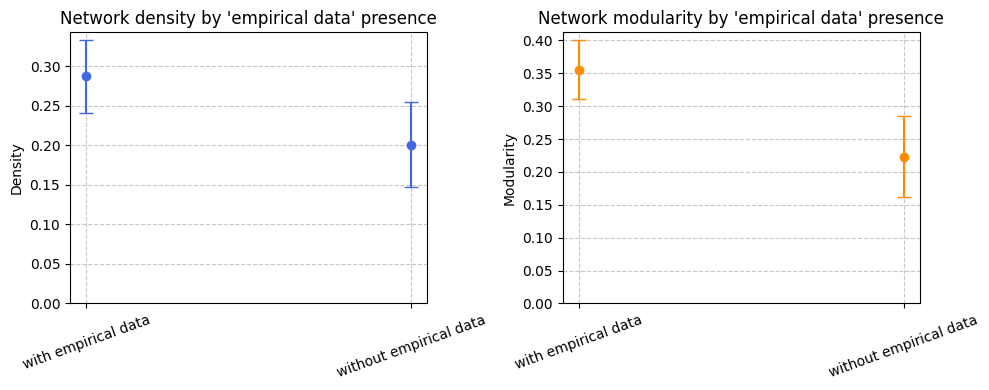

Top betweenness node in networks WITHOUT 'empirical data':


,participant_id,top_betweenness_node,top_betweenness_value
0,cmh1trlci0002sa278d3vv3ip,community,0.156944
3,cmh1uot9n000osa27eayyicd9,AI,0.000000
8,cmh20nti10021sa2781v0n7gr,individual,0.636364
9,cmh20p3iy0027sa27jqf9dcog,knowledge,0.319697
10,cmh20pce1002asa27bbo97iav,analysis,0.666667
13,cmh2780t1002osa278qk4yn4v,AI,0.513889
16,cmh4n1pe9003gsa27d06mabf0,AI,0.000000


Betweenness of 'empirical data' in networks that HAVE it:


,participant_id,empirical_data_betweenness,top_betweenness_node,top_betweenness_value
1,cmh1u7a3d000bsa27gwe0vmf6,0.106481,AI,0.476852
2,cmh1ulurw000lsa2750fqbpip,0.268519,ethics,0.500000
4,cmh1w9kqc0011sa27sx6ud8sm,0.119394,empirical data,0.119394
5,cmh200ziw001hsa27kc2dl64f,0.140606,community,0.182727
6,cmh205bqc001qsa273cbrl5cg,0.000000,technology,0.088889
7,cmh20bfbo001vsa27rn1wly2f,0.045455,context,0.418182
11,cmh20rd26002dsa27jo124g0a,0.000000,ethics,0.472222
12,cmh21d16h002ksa27lkj9ip6g,0.018182,empirical data,0.018182
14,cmh291q1v002vsa27a241pgye,0.000000,ethics,0.200000
15,cmh2gexi60035sa27kedegg6s,0.000000,social norms,0.566667


In [17]:
df = pd.read_csv('./data/df_alter.csv')
# Load the aggregate edge list
edges = pd.read_csv("./edge_counts_edgelist.csv")

# Create the graph
G_all = nx.Graph()
for _, row in edges.iterrows():
    G_all.add_edge(row['source'], row['target'], weight=row['weight'])
    
# Degree centrality (how many unique connections)
degree = dict(G_all.degree())

# Weighted degree (sum of edge weights)
strength = dict(G_all.degree(weight='weight'))

# Betweenness centrality (bridging potential)
betweenness = nx.betweenness_centrality(G_all, weight='weight', normalized=True)

out_counts = (
    df[df['in_gcc'] == False]
    .groupby('name')
    .size()
    .rename('out_of_gcc_count')
)

agg_df = pd.DataFrame({
    'name': list(G_all.nodes()),
    'degree': [degree.get(n, 0) for n in G_all.nodes()],
    'strength': [strength.get(n, 0) for n in G_all.nodes()],
    'betweenness': [betweenness.get(n, 0) for n in G_all.nodes()]
}).merge(out_counts, on='name', how='left').fillna({'out_of_gcc_count': 0})

latent_bridges = agg_df[
    (agg_df['out_of_gcc_count'] >= 2) &
    (agg_df['betweenness'] >= agg_df['betweenness'].quantile(0.75))
]

print(agg_df[['name', 'betweenness']].sort_values('betweenness', ascending=False))

# --- Focused comparison: density & modularity vs presence of "inequality" ---
import ast, numpy as np, pandas as pd, networkx as nx
import matplotlib.pyplot as plt
from networkx.algorithms import community as nx_comm

UUID_COL = "networkCanvasUUID"
NAME_COL = "name"
CONNECTED_COL = "connected_concepts"
PART_COL = "participant_id"
FOCUS_CONCEPT = "empirical data"

def parse_connected(cell):
    if pd.isna(cell):
        return []
    if isinstance(cell, (list, tuple)):
        return [str(x) for x in cell]
    s = str(cell).strip()
    if s == "":
        return []
    try:
        val = ast.literal_eval(s)
        if isinstance(val, (list, tuple)):
            return [str(x) for x in val]
    except Exception:
        pass
    s2 = s.strip("[]() ")
    if not s2:
        return []
    return [p.strip().strip("'\"") for p in s2.split(",") if p.strip()]

def build_participant_graph(sub):
    id_to_name = {str(r[UUID_COL]): r[NAME_COL] for _, r in sub.iterrows() if pd.notna(r.get(UUID_COL))}
    G = nx.Graph()
    for _, r in sub.iterrows():
        name = r[NAME_COL]
        if pd.notna(name):
            G.add_node(name)
    for _, r in sub.iterrows():
        src_uuid = str(r[UUID_COL])
        src_name = id_to_name.get(src_uuid)
        if src_name is None:
            continue
        for nb in parse_connected(r.get(CONNECTED_COL, "")):
            nb = str(nb)
            tgt_name = id_to_name.get(nb)
            if tgt_name and src_name != tgt_name:
                G.add_edge(src_name, tgt_name)
    return G

def compute_modularity(G):
    if G.number_of_edges() == 0 or G.number_of_nodes() < 3:
        return np.nan
    try:
        comms = list(nx_comm.greedy_modularity_communities(G))
        return nx_comm.modularity(G, comms)
    except Exception:
        return np.nan

# --- Compute metrics per participant ---
rows = []
for pid, sub in df.groupby(PART_COL):
    G = build_participant_graph(sub)
    betweenness = nx.betweenness_centrality(G, normalized=True) if G.number_of_edges() > 0 else {}
    top_node = max(betweenness, key=betweenness.get) if betweenness else None
    top_value = betweenness.get(top_node, np.nan) if betweenness else np.nan

    rows.append({
        "participant_id": pid,
        "has_inequality": FOCUS_CONCEPT in G.nodes,
        "density": nx.density(G),
        "modularity": compute_modularity(G),
        "top_betweenness_node": top_node,
        "top_betweenness_value": top_value,
        "empirical_data_betweenness": betweenness.get(FOCUS_CONCEPT, np.nan)
    })

metrics = pd.DataFrame(rows)

# split groups
with_ineq = metrics[metrics["has_inequality"]]
without_ineq = metrics[~metrics["has_inequality"]]

# compute group means & error bars
summary = pd.DataFrame({
    "group": ["with empirical data", "without empirical data"],
    "density_mean": [with_ineq["density"].mean(), without_ineq["density"].mean()],
    "density_sem": [with_ineq["density"].std(ddof=1)/np.sqrt(len(with_ineq)), without_ineq["density"].std(ddof=1)/np.sqrt(len(without_ineq))],
    "modularity_mean": [with_ineq["modularity"].mean(), without_ineq["modularity"].mean()],
    "modularity_sem": [with_ineq["modularity"].std(ddof=1)/np.sqrt(len(with_ineq)), without_ineq["modularity"].std(ddof=1)/np.sqrt(len(without_ineq))]
})

display(summary)

# Plot chart with error bars
fig, ax = plt.subplots(1,2, figsize=(10,4))

# Density
ax[0].errorbar(x=[0,1],
               y=summary["density_mean"],
               yerr=summary["density_sem"],
               fmt='o', capsize=5, color='royalblue')
ax[0].set_xticks([0,1])
ax[0].set_xticklabels(summary["group"], rotation=20)
ax[0].set_ylabel("Density")
ax[0].set_title("Network density by 'empirical data' presence")
ax[0].set_ylim(bottom=0)
ax[0].grid(True, linestyle='--', alpha=0.7)

# Modularity
ax[1].errorbar(x=[0,1],
               y=summary["modularity_mean"],
               yerr=summary["modularity_sem"],
               fmt='o', capsize=5, color='darkorange')
ax[1].set_xticks([0,1])
ax[1].set_xticklabels(summary["group"], rotation=20)
ax[1].set_ylabel("Modularity")
ax[1].set_title("Network modularity by 'empirical data' presence")
ax[1].set_ylim(bottom=0)
ax[1].grid(True, linestyle='--', alpha=0.7) 


plt.tight_layout()
plt.show()

# Highest-betweenness nodes in networks without inequality 
print("Top betweenness node in networks WITHOUT 'empirical data':")
display(without_ineq[["participant_id", "top_betweenness_node", "top_betweenness_value"]])

# Betweenness of 'inequality' in networks that include it 
print("Betweenness of 'empirical data' in networks that HAVE it:")
display(with_ineq[["participant_id", "empirical_data_betweenness", "top_betweenness_node", "top_betweenness_value"]])

Individual networks with empirical data as a concept (10) seem to be more modular than networks without (7)

### 2 Race 2 Ethnicity

In [18]:
df_alters = pd.read_csv('./data/df_alter.csv')

# distance = np.linalg.norm([x - 0.5, y - 0.5])
# apply for rows rather than columns is axis=1
df_alters['distance'] = df_alters.apply(lambda row: np.linalg.norm([row['user_layout_x'] - 0.5, row['user_layout_y'] - 0.5]), axis=1)

# averages of Euclidean distance for every alter
df_concepts_2 = df_alters[["name","distance"]].groupby("name").agg(["count","mean"])
df_concepts_2.columns = ["mentions","distance"]

# Sort the concepts so that least distance is on top.
df_concepts_2.sort_values("distance",ascending=False, inplace=True)
print(df_concepts_2.head(5))

# non-averaged Euclidean distance broken down by user
alter_distance_by_user = df_alters.loc[df_alters['name'] == 'race-ethnicity']
print(alter_distance_by_user[["name", "secret_word", "distance"]])

                 mentions  distance
name                               
user experience         2  0.284306
art                     1  0.266815
race-ethnicity          2  0.244463
optimisation            6  0.230239
social networks         7  0.227122
               name secret_word  distance
29   race-ethnicity   porcupine  0.188387
113  race-ethnicity    helloOII  0.300540


The merged network uses the average Euclidean distance of an alter from the ego. 

There are only 2 people who put "race-ethnicity" on their sociograms, and because their dstances are far apart and the sample size is small (meaning that *porcupine* placed "race-ethnicity" closer to the center and *helloOII* placed it further) the averaged distance does a poor job of merging these positions. 

### Bernie's Theory

In [19]:
unique_secret_words = df_alters['secret_word'].unique()
print(unique_secret_words)
food_secret_words = ['falafel', 'marmite', 'peaches', 'peanuts', 'apples', 'cookie']

food = {}

# get closest concepts for each ego with a food related secret word
for i in food_secret_words:
    alter_distance_by_user = df_alters.loc[df_alters['secret_word'] == i]
    smallest_distance = alter_distance_by_user.nsmallest(3, 'distance')
    name = str(smallest_distance["name"].values[0:3])
    food[i] = name

print(food['peaches'])
# 'peaches': "['identity' 'structure' 'theory']", #ALL guiding concepts

['falafel' 'marmite' 'porcupine' 'cats' 'random' 'space' 'peaches'
 'Dolphin' 'triceratops' 'test' 'helloOII' 'peanuts' 'apples' 'cat' 'Gem'
 'cookie']
['identity' 'structure' 'theory']


Of 'peaches' top concepts by euclidean distance from center, the top 3 fall into our 'guiding concepts' category. Fitting for 'peaches' role as the course provider

### To AI or Not To AI?

In [20]:
# Load raw data
df = pd.read_csv('data/df_alter.csv')

# Find which participants mentioned AI
ai_participants = df[df['name'] == 'AI']['participant_id'].unique()
print(f"Total participants: {df['participant_id'].nunique()}")
print(f"Participants who mentioned AI: {len(ai_participants)} ({len(ai_participants)/df['participant_id'].nunique()*100:.0f}%)")

# For each concept, check if it co-occurred with AI in any individual network
concept_stats = []
for concept in df['name'].unique():
    if concept == 'AI':
        continue
    concept_participants = df[df['name'] == concept]['participant_id'].unique()
    cooccurs_with_ai = len(set(concept_participants) & set(ai_participants)) > 0
    
    concept_stats.append({
        'concept': concept,
        'total_mentions': len(concept_participants),
        'cooccurs_with_ai': cooccurs_with_ai
    })

stats_df = pd.DataFrame(concept_stats)

# Compare groups
with_ai = stats_df[stats_df['cooccurs_with_ai'] == True]
without_ai = stats_df[stats_df['cooccurs_with_ai'] == False]

print(f"\nConcepts WITH AI: n={len(with_ai)}, avg mentions={with_ai['total_mentions'].mean():.1f}")
print(f"Concepts WITHOUT AI: n={len(without_ai)}, avg mentions={without_ai['total_mentions'].mean():.1f}")
print(f"Ratio: {with_ai['total_mentions'].mean() / without_ai['total_mentions'].mean():.2f}x")

# Statistical test
t_stat, p_value = stats.ttest_ind(with_ai['total_mentions'], without_ai['total_mentions'])
print(f"T-test: t={t_stat:.2f}, p={p_value:.4f}")


Total participants: 17
Participants who mentioned AI: 15 (88%)

Concepts WITH AI: n=36, avg mentions=4.7
Concepts WITHOUT AI: n=1, avg mentions=2.0
Ratio: 2.35x
T-test: t=0.86, p=0.3966


The merged network treats all concepts as equal, but individual networks show that some concepts never appear with AI. By merging data, we lose the ability to see which concepts people don't mentally connect with AI.